<hr/>
<b>Nombre</b>: Mateo Bustamante Moreno
<br/>
<b>Cédula</b>: 1001228880
<br/>



### **Objetivo**:
En este proyecto nos proponemos estudiar las denominadas trayectorias de retorno libre a la Luna usando la teoría del CRTBP, apoyado por lo que sabemos el problema de los dos cuerpos.<br>
En este trabajo se usaron 2 sistemas de unidades canonicas, para el sistema 2 cuerpos y para el CRTBP, de tal modo que $(G = 1 [U_l^3/(U_t^2U_m)] )$ <br><br>

In [ ]:
# Instalacion de librerias
!pip install -q pymcel  # libreria general del profe
!pip install -q celluloid # animaciones

In [ ]:
# librerias
import pymcel as pc
import numpy as np
import pandas as pd
import spiceypy as spy
import matplotlib.pyplot as plt

from copy import deepcopy
from tqdm import tqdm # control de tiempos
from celluloid import Camera # animacion
from IPython.display import HTML # ver animacion
from astropy.time import Time # formato de tiempo
from scipy.signal import argrelextrema # extremos de funciones
from astroquery.jplhorizons import Horizons # efemerides
from astropy import constants as cte, units as u # constantes

In [ ]:
# Carga web para masa de la luna
cspi=!wget https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/gm_de440.tpc\
        -O gm_de440.tpc
spy.furnsh('gm_de440.tpc') # Carga kernels

# https://ssd.jpl.nasa.gov/sats/elem/ periodo luna

In [ ]:
# Parametros y constantes importantes
rad   = np.pi/180      # [°] a [rads]
deg   = 1/rad          # [rads] a [°]
au    = cte.au.value   # [m]
G     = cte.G.value    # [m^3/s^2*kg]
G_km  = G/(1000**3)    # [km^3/s^2*kg]
day_2_s = 24*60*60     # [dias] a [s]
s_2_day = 1/day_2_s    # [s] a [dias]
year_2_day = 365.25    # [años] a [dias]
m_2_km = 1/1e3         # [m] a [km]
pi = np.pi

d_moon = 384400 * (1e3) # m
M_earth = cte.M_earth.value      # [kg] masa tierra
M_moon = spy.bodvrd(f'301','GM',1)[1][0]/G_km # [kg]



### **Partiendo del Problema 2 Cuerpos**

##### **Unidades canonicas 2 cuerpos:**

In [ ]:
# unidades canonicas 2 cuerpos
U_l = 36000*1e3              # [m] distancia inicial satelite
U_m = M_earth                # [kg] masa tierra
U_t = (U_l**3/(G*U_m))**0.5  # [s]

# Unidades derivadas
U_v = U_l/U_t                # [U_l/U_t]
Ut_day = U_t*s_2_day         # [dias]

# μ en unidades canónicas
μ = 1                        # [U_l^3/U_t^2]

####**Velocidades en las orbitas:**

- Una nave espacial se encuentra en una órbita circular inicial alrededor de la Tierra a una distancia de 36 000 km del centro de nuestro planeta. Calcule la velocidad que debe tener la nave respecto al centro de la Tierra para que se mantenga en una órbita circular con ese radio.<br><br>

Para un sistema virializado con orbita circular (Orbita Geoestacionaria):
$$ 2K + U = 0$$
$$ m v^2 = --μ m/r $$
$$ v = \sqrt{μ/r }$$


Para una orbita eliptica (Orbita de transferencia de Hohmann). (ecuacion deducida de la cuadratura ERE Energia relativa especifica conservada en todo punto de la orbita, en particular en el periapsis $ϵ=-\mu/2a$ ) :
$$ v = \sqrt{ μ(\frac{2}{r} - \frac{1}{a})}$$ <br>

<p align="center">
<img src=https://i.postimg.cc/R03DhVyJ/IMG-20231025-193400.jpg width="500">
</p>




In [ ]:
# Elementos orbita Hohmann
q_h = 36000*1e3 / U_l   # peri [U_l]
Q_h = 383000*1e3 / U_l  # apo [U_l]
a_h = (q_h + Q_h)/2     # semiejemayor [U_l]


# Velocidad orbita geoestacionaria
v_geo = ( μ  / q_h )**0.5                # [U_v]

# Velocidad orbtial luna (asumiendo orbita circular)
v_moon = ( μ / Q_h )**0.5                # [U_v]

# Velocidad orbita de Hohmann
v_hohman = ( μ*(2/q_h - 1/a_h) )**0.5      # [U_v]

# Velocidad impulso: geoestacionaria->Hohmann
Δv = v_hohman - v_geo                  # [U_v]


- ¿Cuánto debe aumentar la velocidad, $\Delta v$, para que la nave pase de estar en una órbita circular alrededor de la Tierra a una órbita elíptica que tenga perigeo igual a 36 000 km y apogeo igual a la distancia promedio de la Luna (383 000 km)?. A está orbita se la llama *orbita de transferencia de Hohmann*. Obviamente está orbita asume que no existe la Luna.

Teniendo en cuenta que la velocidad de la nave en la orbita circunterrestre es de  $v= 1.0 [U_v] = 3327.4 [m/s]$ el impulso que se le debe dar a la nave para que esta pase a la orbita de transferencia es:
$$ \Delta v \approx  0.352 [U_v] \approx 1171.6 [m/s]$$


- Suponga que la Luna arranca en t = 0, en x = 383 000 km, con una órbita circular alrededor de la Tierra. ¿En qué anomalía verdadera debe recibir la nave el impulso $Δv$ para que cuando llegue al apogeo la Luna se encuentre con la nave?. Esta es la condición básica que define el caso de una transferencia de Hohmann. <br><br>
<p align="center">
<img src=https://i.postimg.cc/hvZNGycc/IMG-20231025-213313.jpg width="400">
</p>


Tomando la anomalia verdadera como el angulo $θ$ que parte del eje $x$ positivo, sobre el que se encuentra la posicion inicial de la luna, en direccion antioraria hasta el punto donde deberia partir la nave en la orbita de transferencia.

Para encontrar este angulo, se crearon las orbitas independientes por pares empleando la funcion ```ncuerpos_solucion```, tierra-orbita nave geoestacionaria, tierra-orbita de Hohmann, y tierra-luna. Asi, modificando la posicion inicial de la orbita de Hohmann sobre la geoestacionaria mediante el angulo $θ$, se buscó cumplir el criterio de coincidir con la posicion de la luna en un tiempo futuro. <br><br>


- Calcule las componentes cartesianas de la posición y la velocidad inicial de la nave respecto de la Tierra en la órbita de Hohmann. <br><br>

Para esto, se contruyó una funcion ```vel(v,θ)``` para encontrar las componentes $(x,y)$ de la velocidad dada su magnitud y la anomalia. Para la posicion similarmente se descompusieron las componentes dado el "radio" inicial geoestacionario $q_h$.    <br>

Finalmente se encontraron varios angulos que pueden cumplir esta condicion de encuentro con el primero con el que se intentó fue $θ = 248°$ y otros cercanos a este como $θ = 249°$

In [ ]:
# Funciones utiles:

def sin(θ): return np.sin(θ)
def cos(θ): return np.cos(θ)

def vel(v,θ):
  # componente de la velocidad en x
  if   0 < θ < pi        : vx = -v*np.abs(sin(θ))
  elif pi < θ < 2*pi     : vx = v*np.abs(sin(θ))
  elif θ == 0 or θ == pi : vx = 0

  # componente de la velocidad en y
  if   pi/2 < θ < 3*pi/2              : vy = -v*np.abs(cos(θ))
  elif 3*pi/2< θ <2*pi or 0<= θ <pi/2 : vy = v*np.abs(cos(θ))
  elif θ == pi/2 or θ == 3*pi/2       : vy = 0

  return vx, vy

In [ ]:
# Anomalia a elegir   :
θ = 249*rad
#---------------------:


# tiempos de integracion en 2cuerpos
ts_2 = np.linspace(0,45,250) #44 [U_t]


# Orbita geocentrica
sistem_g = [ dict(m= M_earth/U_m, r=[0,0,0], v=[0,0,0]),      # tierra
              dict(m= 1e-22, r=[ q_h*cos(θ), q_h*sin(θ), 0],   # nave
                   v= [ vel(v_geo,θ)[0], vel(v_geo,θ)[1], 0])   ]

# Orbita de Hohmann
sistem_h = deepcopy(sistem_g) # tierra-nave hohmann
sistem_h[1]["v"][0] = sistem_h[1]["v"][0] + vel(Δv,θ)[0] # vel en x
sistem_h[1]["v"][1] = sistem_h[1]["v"][1] + vel(Δv,θ)[1] # vel en y

# Orbita de luna
sistem_moon = [ dict(m= M_earth/U_m, r=[0,0,0], v=[0,0,0]),        # tierra
                dict(m= M_moon/U_m, r=[Q_h,0,0], v=[0,v_moon,0]) ] # luna


# integracion
rs_g, vs_g, rps_g, vps_g, cuads_g = pc.ncuerpos_solucion( sistem_g, ts_2 )
rs_h, vs_h, rps_h, vps_h, cuads_h = pc.ncuerpos_solucion( sistem_h, ts_2)
rs_l, vs_l, rps_l, vps_l, cuads_l = pc.ncuerpos_solucion( sistem_moon, ts_2)


# posicion inicial hohmann
q_h*cos(θ), q_h*sin(θ)

# velocidad inicial hohmann
vel(v_hohman,θ)[0] , vel(v_hohman,θ)[1]

(1.2622899108336652, -0.48454769855710655)

#### Grafica de las orbtias por aproximacion **2 cuerpos**

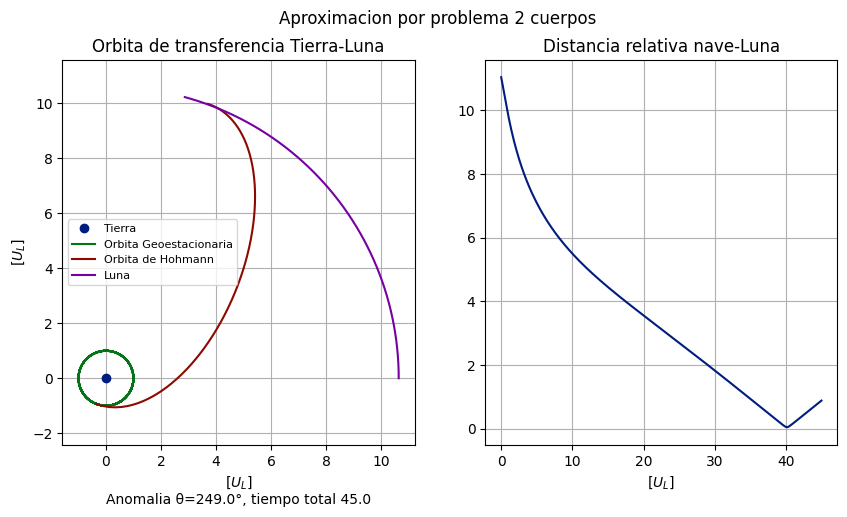

In [ ]:
plt.style.use('seaborn-v0_8-dark-palette')
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,5))
fig.suptitle('Aproximacion por problema 2 cuerpos')

ax[0].set_title('Orbita de transferencia Tierra-Luna')
ax[0].plot(rs_g[0,0,0], rs_g[0,0,1], 'o', label='Tierra')
ax[0].plot(rs_g[1,:,0], rs_g[1,:,1], label='Orbita Geoestacionaria')
ax[0].plot(rs_h[1,:,0], rs_h[1,:,1], label='Orbita de Hohmann')
ax[0].plot(rs_l[1,:,0], rs_l[1,:,1], label='Luna')
ax[0].set_xlabel(f'[$U_L$]\nAnomalia θ={θ*deg:.5}°, tiempo total {ts_2[-1]}')
ax[0].legend(fontsize=8)
ax[0].set_ylabel('[$U_L$]')
ax[0].axis('equal')
ax[0].grid()

ax[1].plot(ts_2, np.linalg.norm( rs_h[1,:,:] - rs_l[1,:,:] , axis=1) )
ax[1].set_title('Distancia relativa nave-Luna')
ax[1].set_xlabel('[$U_L$]')
ax[1].grid()

<br>

### **En el Sistema del CRTBP**

Con estos valores indicativos vamos ahora a simular el sistema Tierra-Luna-Nave y a estudiar la trayectoria del vehículo, tanto en un sistema de referencia inercial, como en un sistema de referencia rotante en el que la Tierra y la Luna están en reposo **(sistema del CRTBP)**. <br><br>

1. Calcule la posición y velocidad inicial de la Tierra en un sistema de referencia inercial en el que el origen está en el centro de masa de la Tierra y la Luna, y la Luna y la Tierra orbitan con un semieje mayor relativo igual a 383 000 km.

In [ ]:
# nuevas unidades canonicas CRTBP
U_l_3bdy = 383000*1e3   # [m]
U_m_3bdy = M_earth + M_moon   # [kg]
U_t_3bdy = (U_l_3bdy**3/(G*U_m_3bdy))**0.5  # [s]

# unidades derivadas
U_v_3bdy = U_l_3bdy / U_t_3bdy # [m/s]

μ = 1  # G  * (m1+m2)

# Parametros del problema en unidades canónicas
alfa = M_moon/(M_earth + M_moon) # mu 2
mu2 = alfa
mu1 = M_earth/(M_earth + M_moon)
mu =  G*(M_moon)

# el periodo es el mismo de la luna
P = 27.322*day_2_s / U_t_3bdy # U_t
omega = 2*pi/P


In [ ]:
# parametros para el CRTBP
a = 383000*1e3
mu =  G*(M_moon + M_earth)
mu1 =  G*M_earth
mu2 =  G*M_moon
M = M_moon + M_earth


# calculo velocidad orbital luna
x2 = M_earth/M * a               # posicion luna (alpha)
v2 = M_earth/M * (mu1/(x2))**0.5 # velocidad orbital luna [m/s]

# calculo velocidad orbital tierra
x1 =  M_moon/M * a                # posicion tierra (1-alpha)
v1 = M_moon/M * (mu2/(x1))**0.5   # velocidad orbital tierra [m/s]


2. Calcule ahora la posición y velocidad inicial de la nave en el sistema de referencia inercial y en el momento en el que recibe el impulso Para ello simplemente sume a la posición y velocidad inicial de la nave, la posición y velocidad inicial de la Tierra en t = 0.

En este punto, para ajustar la obita de libre retorno se realizaron variaciones en la velocidad, pues la velocidad que se habia calculado previamente para la orbita de Hohmann era lo suficientemente grande para que la nave llegara a la luna pero no retornara, por esta razon, para disminuir su velocidad se le restó $k$ veces la velocidad de la tierra, que es relativamente pequeña comparada con la velocidad inicial de la nave en la orbita de transferencia (aproximadamente $360.7$ veces mas pequeña), se encontró que para valores de $k$ como $22.4$ (choca la luna) $25.9$ (el retorno llega muy cerca o choca la tierra), mientras que valores como $26.4$, $27.4$ que fue el que se escogio, pues dan un resultado mas estable con un retorno similar a la distancia de la tierra al punto desde que partió la obita de transferencia. por otro lado para valores como $35$ en adelante aparecen regiones de exclusion y superficies de velocidad 0.

In [ ]:
# posicion inicial nueva Hohmann
q_x_new = q_h * U_l / U_l_3bdy * cos(θ) - alfa # camabian las componentes de la orbita de hoh, no su radio q
q_y_new = q_h * U_l / U_l_3bdy * sin(θ) - alfa


# Variacion de la velocidad inicial en Hohmann:
k = 27.4
v_new_h = v_hohman*U_v/U_v_3bdy - k * v1/U_v_3bdy




3. Simule el movimiento de la nave usando la rutina `crtbp_solucion` y mire cómo es la trayectoria, tanto en el sistema rotante como en el sistema de referencia inercial. <br><br>
Calcule la constante de Jacobi, grafique las regiones de exclusión y la superficie de cero velocidad correspondiente a este valor de la constante de Jacobi.

In [ ]:
# tiempos de integracion en CRTBP
ts_3 = np.linspace(0, 1.65, 500)

r_rot, v_rot, r_in, v_in, r1_in, r2_in = pc.crtbp_solucion( \
                                alfa, [q_x_new, q_y_new,0],
                                [vel(v_new_h,θ)[0],vel(v_new_h,θ)[1],0], ts_3)

#### Grafica de las trayectorias en sistema Rotenate e Inercial

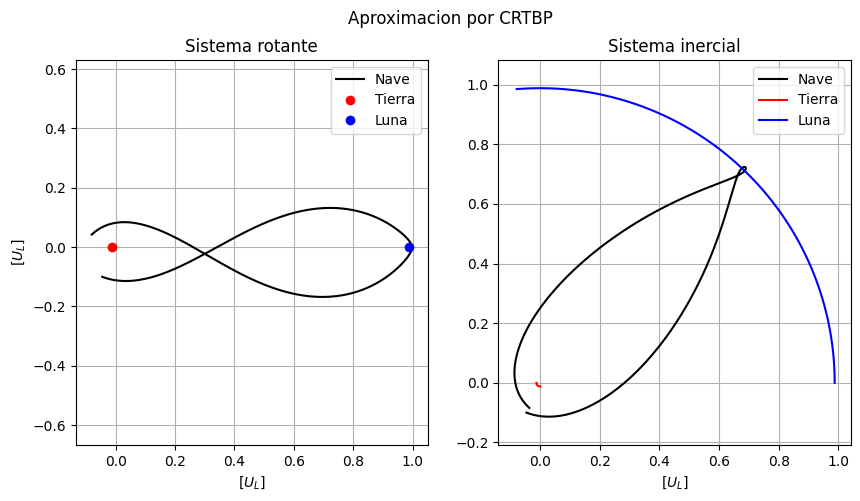

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(10,5))
fig.suptitle('Aproximacion por CRTBP')

ax[0].set_title("Sistema rotante")
ax[0].plot(r_rot[:,0] ,r_rot[:,1],'k-', label='Nave')
ax[0].plot([-alfa], [0],'ro', label='Tierra')
ax[0].plot([1-alfa], [0],'bo', label='Luna')
ax[0].set_ylabel('[$U_L$]')
ax[0].set_xlabel('[$U_L$]')
ax[0].axis('equal')
ax[0].legend()
ax[0].grid()

ax[1].set_title("Sistema inercial")
ax[1].plot(r_in[:,0], r_in[:,1],'k-', label='Nave')
ax[1].plot(r1_in[:,0], r1_in[:,1],'r-', label='Tierra')
ax[1].plot(r2_in[:,0], r2_in[:,1],'b-', label='Luna')
ax[1].set_xlabel('[$U_L$]')
ax[1].axis('equal')
ax[1].legend()
ax[1].grid()

plt.show()

#### Constante de Jacobi, Regiones de exclusion y Superficies de velocidad 0

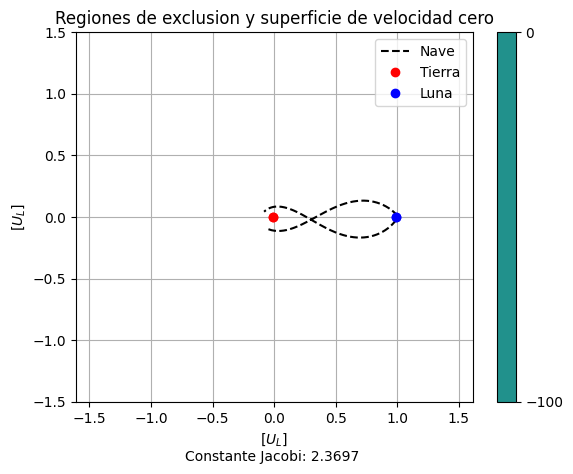

In [ ]:
# Constante de Jacobi para la nave
CJp = pc.constante_jacobi(alfa, r_rot, v_rot)[0]

# Cálculo de constante en malla
ran = 1.5

X, Y = np.meshgrid(np.linspace(-ran,ran,40), np.linspace(-ran,ran,40))
Z = 0*np.ones_like(X)

V2 = 2*(1-alfa)/((X+alfa)**2+Y**2+Z**2)**0.5 + \
     2*alfa/((X-(1-alfa))**2+Y**2+Z**2)**0.5 + \
     X**2 + Y**2 - CJp


# Gráfico de V^2 contornos
c = plt.contour(X, Y, V2, levels=[0], colors='k')
c = plt.contourf(X, Y, V2, levels=[-100,0])

plt.title('Regiones de exclusion y superficie de velocidad cero')
plt.colorbar(c)
plt.plot(-alfa,0,'ro')
plt.plot(1-alfa,0,'bo')

plt.plot(r_rot[:,0],r_rot[:,1],'k--', label='Nave')
plt.plot([-alfa],[0],'ro', label='Tierra')
plt.plot([1-alfa],[0],'bo', label='Luna')
plt.xlabel(f'[$U_L$]\nConstante Jacobi: {CJp:.5} ')
plt.ylabel('[$U_L$]')
plt.axis('equal')
plt.legend()
plt.grid()

Para este caso, se obtiene una constante de jacobi relativamente pequeña $2.3697$, lo que causa que la velocidad cuadrada nunca se pueda hacer negativa, de modo que no se evidnecian regiones de exclusion ni superficies de velocidad cero. pero como se mencionó antes, si se disminuye aun mas la velocidad de partida de la orbita de transferencia, la constante de jacobi aumenta y las regiones de exclusion surgen.
<br><br>





4. Es posible que en el primer intento no consiga la trayectoria deseada (una trayectoria que lleve la nave hasta la Luna y que después la regrese a la Tierra). Modifique con cuidado las condiciones iniciales de la nave (en especial la velocidad incial) hasta que consiga una o varias trayectorias de retorno libre en el sistema. <br><br>
Calcule el apogeo y el perigeo de la trayectoria de la nave respecto a la Tierra y el tiempo que tardaría la nave en salir de la órbita alrededor de la Tierra y en regresar a un punto cercano.

In [ ]:
# distancia relativa tierra-nave
d_tierra_nave = np.linalg.norm(r_in[:,:]-r1_in[:,:], axis=1 )

# apogeo real
apo = max(d_tierra_nave)

# perigeo real
peri = min(d_tierra_nave)

# tiempo de viaje
t_viaje = ts_3[-1]


print(f'Apogeo {apo:.4f} [U_l] = {apo*U_l_3bdy*m_2_km:.4f} km')
print(f'Perigeo {peri:.4f} [U_l] = {peri*U_l_3bdy*m_2_km:.4f} km')
print(f'Tiempo de viaje {t_viaje:.5f} [U_t] = {t_viaje*U_t_3bdy*s_2_day:.4f} d')

Apogeo 1.0103 [U_l] = 386948.0555 km
Perigeo 0.0755 [U_l] = 28920.8815 km
Tiempo de viaje 1.65000 [U_t] = 7.1260 d


###**Conclusiones**


 En un principio, para calcular el ángulo se tomó uno que se acercara a la órbita de la luna sin más, el único criterio era que la órbita de hohmann intersecara casi paralelamente a la órbita lunar, que en un tiempo t, la nave y la luna se encontraran casi en el mismo punto, no obstante, con el avance del código, a la hora de intentar recrear una órbita de retorno libre, se evidencio que para que se dé, la nave en el tiempo t, debe llegar un poco más "adelantada" a la luna, para que la atracción gravitacional la pueda capturar y enviarla de retorno, por el contrario, si en ese mismo tiempo t, la nave llegaba después de que la luna haya cruzado la intersección, la nave salía disparada hacia el infinito. por otro lado, si ambos objetos llegan muy justos, primero la nave, esta tendrá un gran acercamiento a la luna, pero puede que en su retorno no se acerque mucho a la tierra.
la constante de jacobi, en particular la velocidad y la variación que se le haga es relevante a la hora de encontrar los criterios de las zonas de exclusión y encontrar una orbita de retorno libre adecuada, pero la anomalía desde la que parte la nave desde la órbita geoestacionaria también lo es.
Por otra parte el tiempo de viaje de $7.126$ d parece ser un poco mayor al que le tomó al apolo 11 que fue de aproximadamente de $3$ dias, esta diferencia se puede deber a la orbita de partida geoestacionaria, la velocidad de impulso para entrar a la orbita de transferencia y la trayectoria de la orbita en sí, ademas del uso de motores para correción de trayectoria.